# Évaluation multicatégorielle de la recherche sémantique

Cette expérimentation mesure Recall@10, MRR@10 et le temps moyen de réponse sur 90 requêtes tests, réparties entre les neuf catégories de la collection Qdrant équilibrée de 900 documents.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / 'evaluation' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Projet : {PROJECT_ROOT}')

Projet : /Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel


In [2]:
from evaluation.evaluate_balanced_collection import main as executer_evaluation

executer_evaluation()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   Scénario  Recall@10   MRR@10  Temps (ms)
Avec filtre   0.922222 0.791817    5.505942
Sans filtre   0.900000 0.779272    4.791232
   Scénario                      Catégorie  Recall@10   MRR@10  Temps (ms)
Avec filtre                     Actualités        1.0 0.456667    5.018350
Avec filtre     Actualités internationales        0.9 0.900000    5.824517
Avec filtre        Droit et réglementation        0.9 0.714286    7.096433
Avec filtre                 FQuADRetrieval        0.5 0.155397    5.459712
Avec filtre             Mémoire académique        1.0 0.950000    4.644250
Avec filtre Santé et recherche biomédicale        1.0 1.000000    5.042400
Avec filtre       Sciences et technologies        1.0 1.000000    5.079742
Avec filtre                          Sport        1.0 1.000000    5.915387
Avec filtre        Économie et entreprises        1.0 0.950000    5.472687
Sans filtre                     Actualités        1.0 0.456667    5.932333
Sans filtre     Actualités internationales 

In [3]:
summary = pd.read_csv(RESULTS_DIR / 'balanced_collection_summary_metrics.csv')
by_category = pd.read_csv(RESULTS_DIR / 'balanced_collection_metrics.csv')
manifest = json.loads((RESULTS_DIR / 'balanced_collection_summary.json').read_text())
print(f"Collection : {manifest['collection']}")
print(f"Documents : {manifest['document_count']} ; requêtes tests : 90")
print('Documents par catégorie :', manifest['categories'])
summary

Collection : experiment_multicategory_900
Documents : 900 ; requêtes tests : 90
Documents par catégorie : {'Actualités': 100, 'Actualités internationales': 100, 'Droit et réglementation': 100, 'FQuADRetrieval': 100, 'Mémoire académique': 100, 'Santé et recherche biomédicale': 100, 'Sciences et technologies': 100, 'Sport': 100, 'Économie et entreprises': 100}


,Scénario,Recall@10,MRR@10,Temps (ms)
0,Avec filtre,0.922222,0.791817,5.505942
1,Sans filtre,0.900000,0.779272,4.791232


In [4]:
pivot = by_category.pivot(index='Catégorie', columns='Scénario', values='Recall@10')
pivot

Scénario,Avec filtre,Sans filtre
Catégorie,,
Actualités,1.0,1.0
Actualités internationales,0.9,0.9
Droit et réglementation,0.9,0.9
FQuADRetrieval,0.5,0.3
Mémoire académique,1.0,1.0
Santé et recherche biomédicale,1.0,1.0
Sciences et technologies,1.0,1.0
Sport,1.0,1.0
Économie et entreprises,1.0,1.0


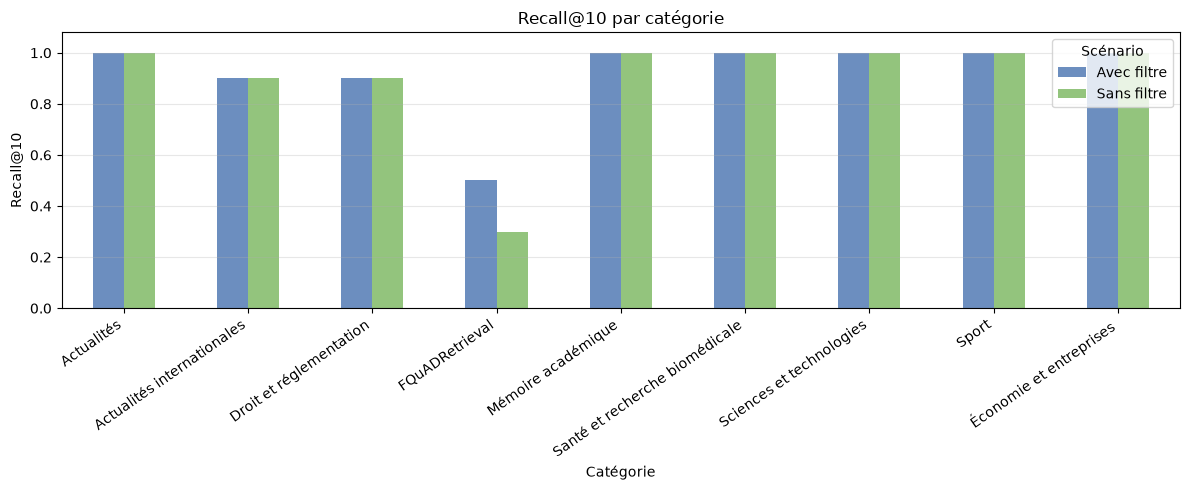

In [5]:
ax = pivot.sort_index().plot.bar(figsize=(12, 5), ylim=(0, 1.08), color=['#6c8ebf', '#93c47d'])
ax.set_title('Recall@10 par catégorie')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Recall@10')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Les fichiers `balanced_collection_metrics.csv` et `balanced_collection_summary_metrics.csv` contiennent les valeurs réellement calculées. Ils alimentent le chapitre 4 du rapport.
